In [1]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as pl

In [2]:
def Plot (img, **kwargs):
    m = img.shape [0]
    n = 2 * m

    x = np.zeros (n)
    r = np.arange (m)
    x [::2] = r
    x [1::2] = r + 1

    y = np.zeros (n)
    y [::2] = img
    y [1::2] = img

    pl.plot (x, y, 'b')

In [3]:
def Stem (img):
    pl.stem (img, linefmt = 'b', markerfmt = 'bo', basefmt = 'b')

In [4]:
image = np.array ([0, 0, 1, 1, 3, 3, 0])

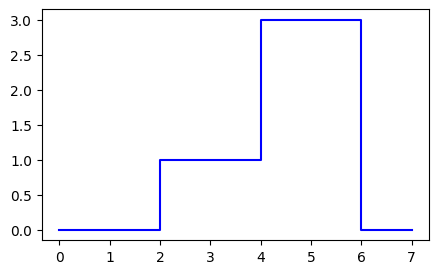

In [5]:
pl.figure (figsize = (5, 3))
Plot (image)

In [6]:
filter = np.array ([0, -1, 1, 0])

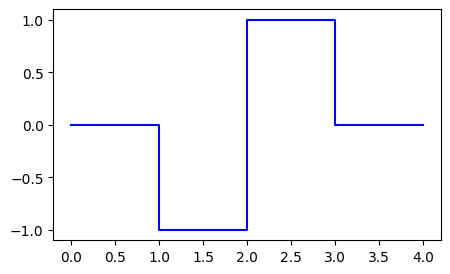

In [7]:
pl.figure (figsize = (5, 3))
Plot (filter)

In [8]:
result = np.correlate (image, filter, mode = 'full')

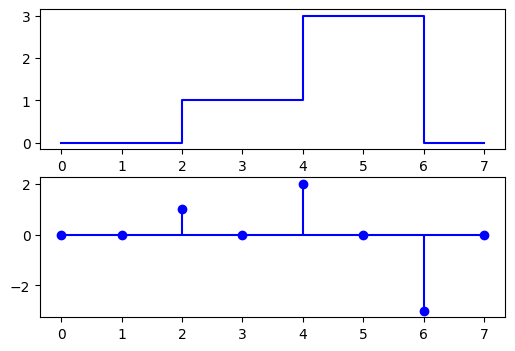

In [9]:
pl.figure (figsize = (6, 4))
pl.subplot (2, 1, 1); Plot (image)
pl.subplot (2, 1, 2); Stem (result [1:-1])

In [10]:
n = 100

In [11]:
img0 = np.array ([float (i >= n // 2) for i in range (n)])

In [12]:
def Edge (img):
    n = img.shape [0]
    edg = np.zeros (n)
    edg [:-1] = img [1:] - img [:-1]
    return edg

In [13]:
edg0 = Edge (img0)

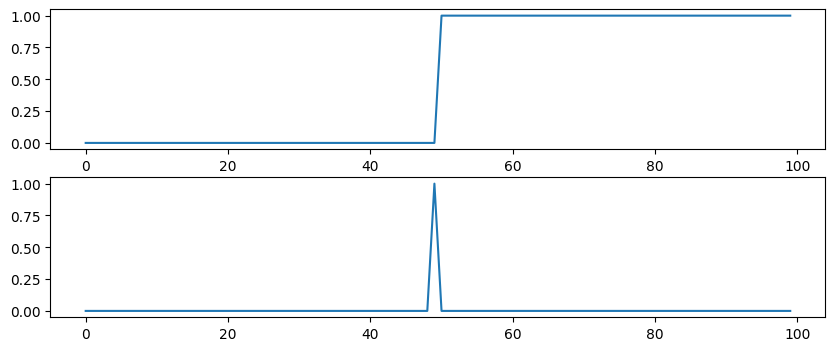

In [14]:
pl.figure (figsize = (10, 4))
pl.subplot (2, 1, 1); pl.plot (img0)
pl.subplot (2, 1, 2); pl.plot (edg0)

In [15]:
amp = 0.5

In [16]:
img = img0 + amp * rd.rand (n)

In [17]:
edg = Edge (img)

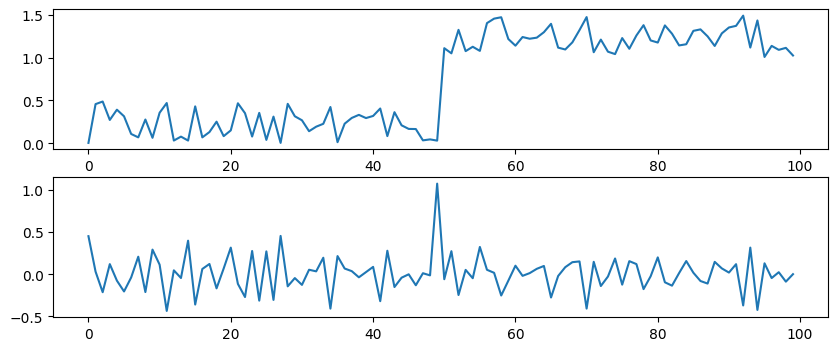

In [18]:
pl.figure (figsize = (10, 4))
pl.subplot (2, 1, 1); pl.plot (img)
pl.subplot (2, 1, 2); pl.plot (edg)

In [19]:
k = np.array ([1, 2, 3, 2, 1])
k = k / np.sum (k)
k

array([0.11111111, 0.22222222, 0.33333333, 0.22222222, 0.11111111])

In [20]:
img1 = np.correlate (img, k, mode = 'valid')

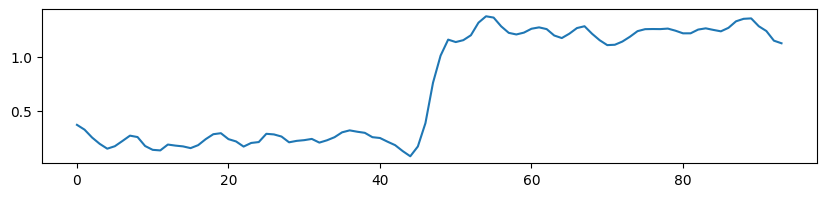

In [21]:
pl.figure (figsize = (10, 2))
pl.plot (img1 [1:-1])

In [22]:
edg1 = Edge (img1)

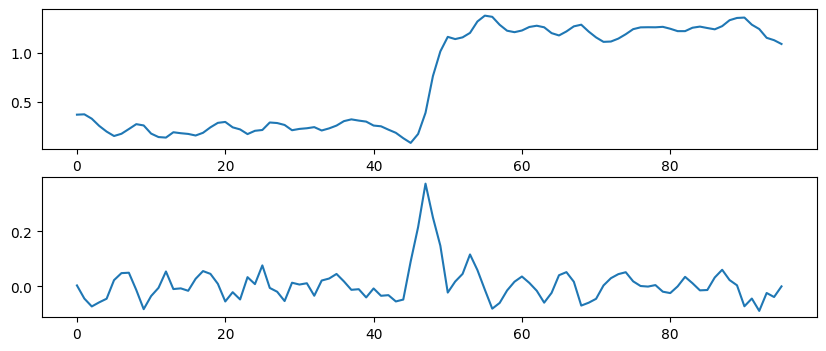

In [23]:
pl.figure (figsize = (10, 4))
pl.subplot (2, 1, 1); pl.plot (img1)
pl.subplot (2, 1, 2); pl.plot (edg1)

In [24]:
def Gauss (sigma, x):
    return np.exp (-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt (2 * np.pi))

In [25]:
def GaussKernel (sigma, radius):
    xx = np.arange (-radius, radius + 1)
    yy = Gauss (sigma, xx)
    return yy / np.sum (yy)

In [26]:
sigma = 1.5
radius = 5

In [27]:
k = GaussKernel (sigma, radius)

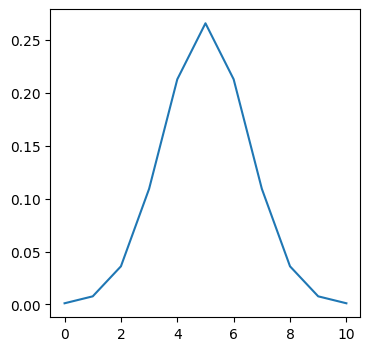

In [28]:
pl.figure (figsize = (4, 4))
pl.plot (k)

In [29]:
img2 = np.convolve (img, k, mode = 'valid')

In [30]:
edg2 = Edge (img2)

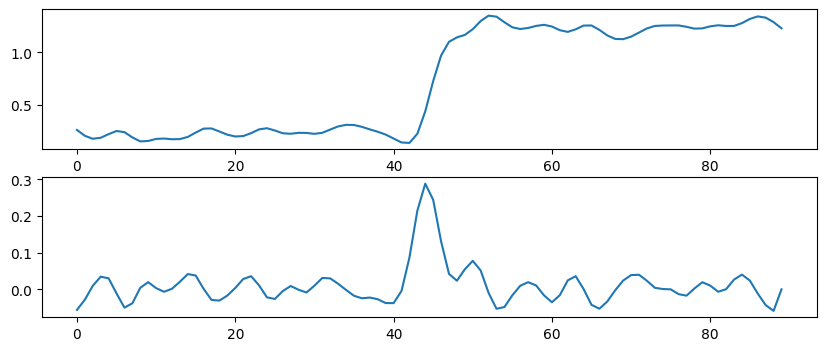

In [31]:
pl.figure (figsize = (10, 4))
pl.subplot (2, 1, 1); pl.plot (img2)
pl.subplot (2, 1, 2); pl.plot (edg2)

In [32]:
def GaussDerived (sigma, x):
    return -x * np.exp (-0.5 * (x / sigma) ** 2) / (sigma ** 3 * np.sqrt (2 * np.pi))

In [33]:
def GaussDerivedKernel (sigma, radius):
    xx = np.arange (-radius, radius + 1)
    yy = GaussDerived (sigma, xx)
    return yy

In [34]:
k = GaussDerivedKernel (sigma, radius)

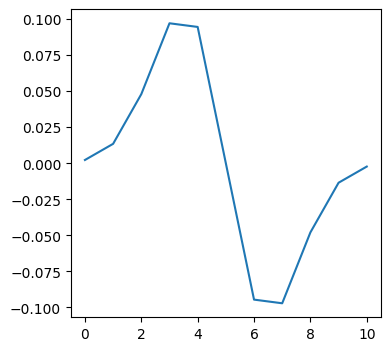

In [35]:
pl.figure (figsize = (4, 4))
pl.plot (k)

In [36]:
edg3 = np.convolve (img, k, mode = 'valid')

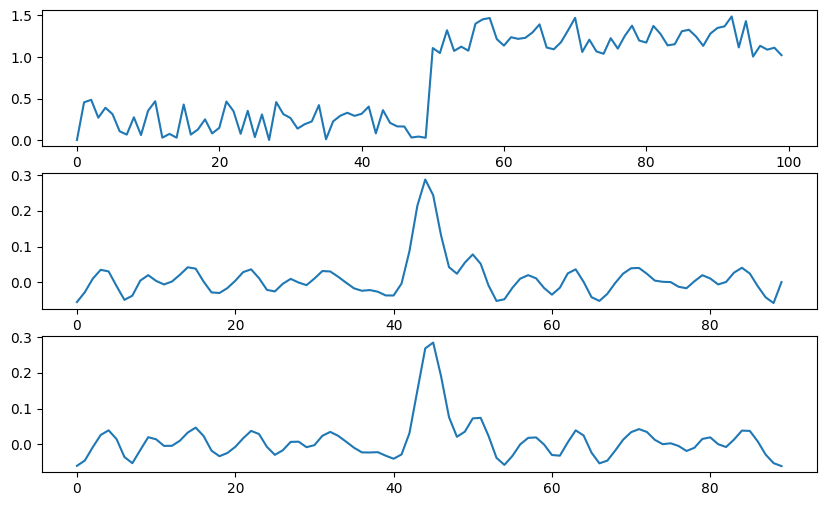

In [37]:
pl.figure (figsize = (10, 6))
pl.subplot (3, 1, 1); pl.plot (img)
pl.subplot (3, 1, 2); pl.plot (edg2)
pl.subplot (3, 1, 3); pl.plot (edg3)